In [92]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [93]:
lr_model = LinearRegression()
rf_model = RandomForestRegressor()

In [94]:
from sklearn.datasets import make_friedman1

x, y = make_friedman1(n_samples=10000, n_features=10, noise=1, random_state=42)


In [95]:
import pandas as pd

In [96]:
df = pd.DataFrame(x, columns=[f"col_{x + 1}" for x in range(x.shape[-1])])
df["target"] = y

In [97]:
from sklearn.model_selection import train_test_split

In [98]:
x_train, x_test, y_train, y_test = train_test_split(x, y)

In [99]:
trained_lr = lr_model.fit(x_train, y_train)
trained_rf = rf_model.fit(x_train, y_train)

In [100]:
rf_predictions = trained_rf.predict(x_test)
lr_predictions = trained_lr.predict(x_test)

In [101]:
pred_df = pd.DataFrame([rf_predictions, lr_predictions]).T

In [102]:
pred_df = pred_df.rename(columns={0: "rf_pred", 1: "lr_pred"})

In [103]:
import matplotlib.pyplot as plt

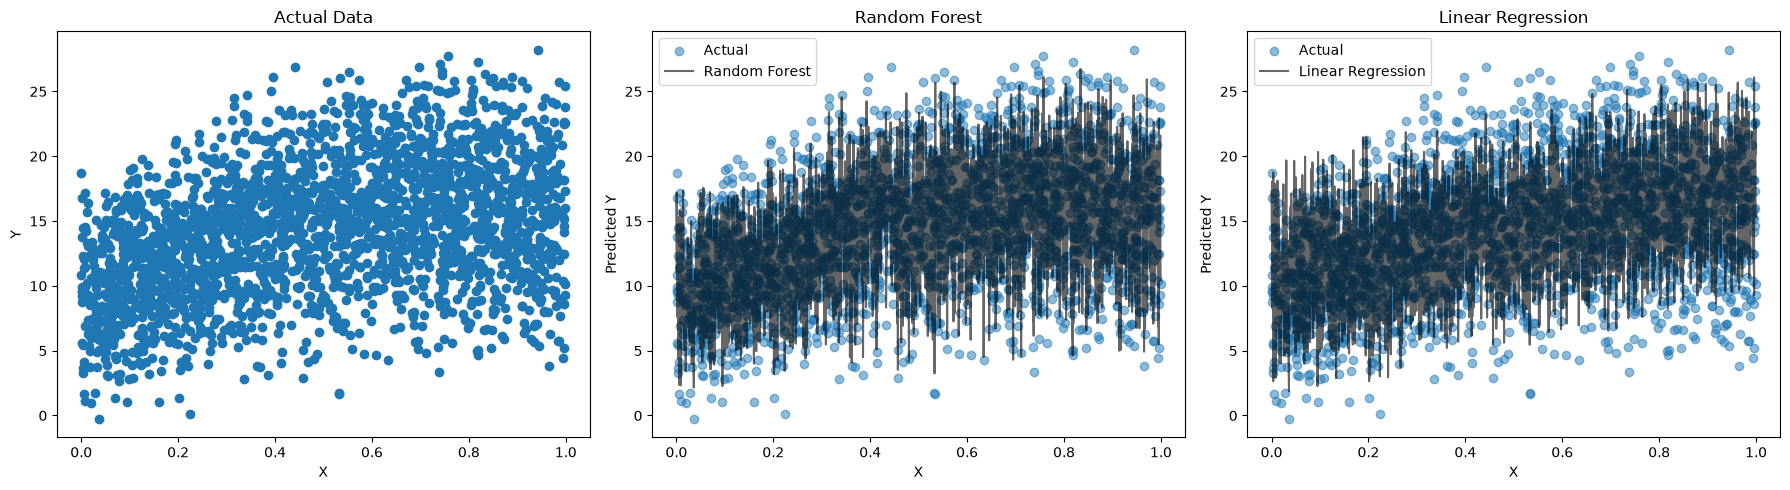

In [104]:
import matplotlib.pyplot as plt
import numpy as np

# Take the first feature
x = x_test[:, 0]

# Sort x so prediction lines are drawn correctly
idx = np.argsort(x)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Actual data
axes[0].scatter(x, y_test)
axes[0].set_title("Actual Data")
axes[0].set_xlabel("X")
axes[0].set_ylabel("Y")

# 2. Random Forest
axes[1].scatter(x, y_test, alpha=0.5, label="Actual")
axes[1].plot(
    x[idx],
    rf_predictions[idx],
    label="Random Forest",
    color="black",
    alpha=0.6,
    linestyle="-",
)
axes[1].set_title("Random Forest")
axes[1].set_xlabel("X")
axes[1].set_ylabel("Predicted Y")
axes[1].legend()

# 3. Linear Regression
axes[2].scatter(x, y_test, alpha=0.5, label="Actual")
axes[2].plot(
    x[idx],
    lr_predictions[idx],
    label="Linear Regression",
    color="black",
    alpha=0.6,
    linestyle="-",
)
axes[2].set_title("Linear Regression")
axes[2].set_xlabel("X")
axes[2].set_ylabel("Predicted Y")
axes[2].legend()

plt.tight_layout()
plt.show()


In [105]:
from sklearn.metrics import mean_absolute_error

rf_mae = mean_absolute_error(y_test, rf_predictions)
lr_mae = mean_absolute_error(y_test, lr_predictions)

print(f"RF MAE: {rf_mae:.4g}")
print(f"LR MAE: {lr_mae:.4g}")


RF MAE: 1.191
LR MAE: 2.053


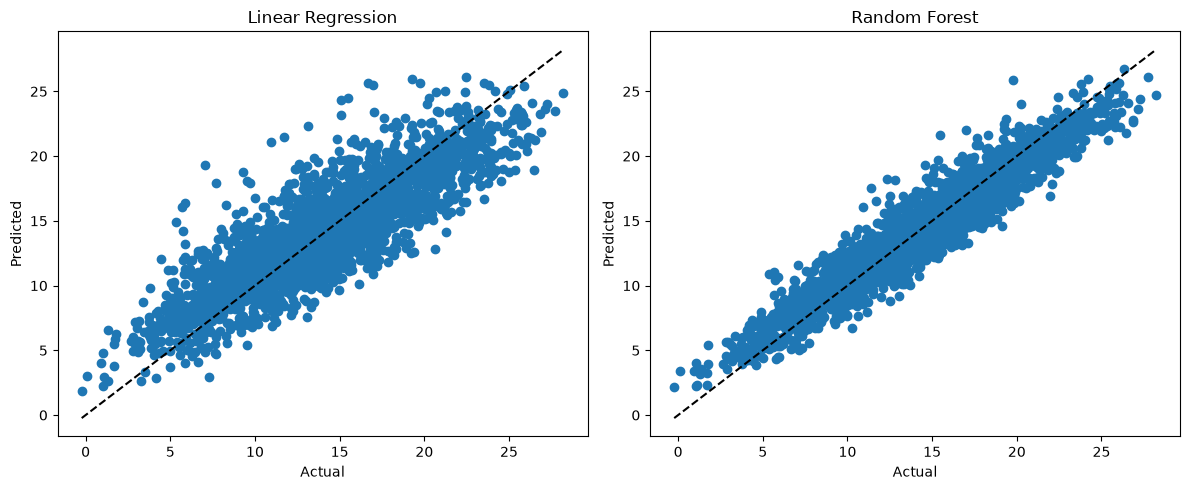

In [106]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Linear Regression
axes[0].scatter(y_test, lr_predictions)
axes[0].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="black",
)
axes[0].set_title("Linear Regression")
axes[0].set_xlabel("Actual")
axes[0].set_ylabel("Predicted")

# Random Forest
axes[1].scatter(y_test, rf_predictions)
axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--",
    color="black",
)
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Actual")
axes[1].set_ylabel("Predicted")

plt.tight_layout()
plt.show()
